# Getting Started with SWIPER-SIM Simulator

In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

## Simulating Window Decoding of 10 Lattice Surgery T Gates

In [2]:
from swiper.schedule_experiments import RegularTSchedule, RareTSchedule, RegularTScheduleWithInBetween
from swiper.simulator import DecodingSimulator
import swiper.plot as plotter

import pickle as pkl
import numpy as np

### Fixed Decoder Latency

In [3]:
latency = 14 # us
distance = 7 
scheduling_method = 'sliding' # Sliding Window
speculation_mode = 'separate' # Predictor and decoder are separate 
speculation_accuracy = 0.9
# t_schedule = RegularTSchedule(10, 0)
t_schedule = RegularTSchedule(2, 7)
rare_t_schedule = RareTSchedule(1, 0)

idx inst 2
True  t_gate_bool
IDLE 0 [(0,0)] 7 [] [] [] [] [] [] none False none
INJECT_T 1 [(1,0)] D [] [] [] [] [] [] none True none
MERGE 2 [(1,0),(0,0)] D [] [] [] [] [((0,0),(1,0))] [] none True none
idx inst 10
True  t_gate_bool
IDLE 0 [(0,0)] 7 [] [] [] [] [] [] none False none
INJECT_T 1 [(1,0)] D [] [] [] [] [] [] none True none
MERGE 2 [(1,0),(0,0)] D [] [4,5,6,7] [] [] [((0,0),(1,0))] [] none True none
DISCARD 3 [(1,0)] 0 [] [] [] [] [] [] none True none
MERGE 4 [(1,0),(0,0)] D [2] [] [] [] [((0,0),(1,0))] [4,5,6,7] CONDITIONAL_S True none
Y_MEAS 5 [(1,0)] HALF_D_PLUS_2 [2] [] [] [] [] [4,5,6,7] CONDITIONAL_S True none
IDLE 6 [(0,0)] HALF_D_PLUS_2 [2] [] [] [] [] [4,5,6,7] CONDITIONAL_S True none
DISCARD 7 [(1,0)] 0 [2] [] [] [] [] [4,5,6,7] CONDITIONAL_S True none
IDLE 8 [(0,0)] 7 [] [] [] [] [] [] none False none
INJECT_T 9 [(0,1)] D [] [] [] [] [] [] none True none
MERGE 10 [(0,1),(0,0)] D [] [] [] [] [((0,0),(0,1))] [] none True none
idx inst 8
False  t_gate_bool
IDLE 0 [

In [4]:
# have set rng
seed = 123456
rng = np.random.default_rng(seed)

simulator = DecodingSimulator()
# success, sim_params, device_data, window_data, decoding_data = simulator.run(
success_data, full_window_arr, _ = simulator.run(
    schedule=t_schedule.schedule,
    distance=distance,
    scheduling_method=scheduling_method,
    decoding_latency_fn=lambda _: latency,
    speculation_mode=speculation_mode,
    speculation_latency=1,
    speculation_accuracy=speculation_accuracy,
    progress_bar=True,
    rng=123456, # rng=rng
    need_full_window=True, # True
    # max_parallel_processes=2,
    # window_parameters='window_parameters_file.json'
)
success, sim_params, device_data, window_data, decoding_data = success_data

ax = plotter.plot_device_schedule_trace(device_data, spacing=1)
ax.set_axis_off()

FULL WINDOW DAG STEP BEGIN---------------------------------
FULL WINDOW DAG STEP BEGIN---------------------------------


KeyboardInterrupt: 

In [5]:
# have set rng
seed = 123456
rng = np.random.default_rng(seed)

simulator = DecodingSimulator()
# success, sim_params, device_data, window_data, decoding_data = simulator.run(
success_data, full_window_arr, _ = simulator.run(
    schedule=t_schedule.schedule,
    distance=distance,
    scheduling_method=scheduling_method,
    decoding_latency_fn=lambda _: latency,
    speculation_mode=None, # speculation_mode,
    speculation_latency=1,
    speculation_accuracy=speculation_accuracy,
    progress_bar=True,
    rng=123456, # rng=rng
    need_full_window=False, # True
    # window_parameters='window_parameters_file.json'
)
success, sim_params, device_data, window_data, decoding_data = success_data

ax = plotter.plot_device_schedule_trace(device_data, spacing=1)
ax.set_axis_off()

FULL WINDOW DAG STEP BEGIN---------------------------------


KeyboardInterrupt: 

In [ ]:
simulator = DecodingSimulator()
# success, sim_params, device_data, window_data, decoding_data = simulator.run(
#     schedule=rare_t_schedule.schedule,
#     distance=distance,
#     scheduling_method=scheduling_method,
#     decoding_latency_fn=lambda _: latency,
#     speculation_mode=speculation_mode,
#     speculation_latency=1,
#     speculation_accuracy=speculation_accuracy,
#     progress_bar=True,
# )

success_data, _, _ = simulator.run(
    schedule=rare_t_schedule.schedule,
    distance=distance,
    scheduling_method=scheduling_method,
    decoding_latency_fn=lambda _: latency,
    speculation_mode=speculation_mode,
    speculation_latency=1,
    speculation_accuracy=speculation_accuracy,
    progress_bar=True,
    rng=45, # rng=rng
    need_full_window=True,
    # poison_policy='descendants' # added for more mispredictions restarts
)
success, sim_params, device_data, window_data, decoding_data = success_data

ax = plotter.plot_device_schedule_trace(device_data, spacing=1)
ax.set_axis_off()

FULL WINDOW DAG STEP BEGIN---------------------------------
full window arr  []
full window dag  None
discard 1  {(1, 0), (0, 0)} {(1, 0)}
discard 1  {(1, 0), (0, 0)} {(1, 0)}
discard 1  {(0, 1), (0, 0)} {(0, 1)}
discard 1  {(0, 1), (0, 0)} {(0, 1)}
discard 1  {(0, 0)} {(0, 0)}
schedule insts device manager after y_meas [InstructionTask(instruction_idx=0, instruction=Instruction(name='IDLE', idx=0, patches=frozenset({(0, 0)}), duration=3, conditioned_on_idx=frozenset(), conditional_dependencies=frozenset(), conditioned_on_completion_idx=frozenset(), conditional_completion_dependencies=frozenset(), merge_faces=frozenset(), group_instr_indices=frozenset(), group_name='', t_gate_bool=False, actual_duration_time=None), start_round=-1, end_round=-1), InstructionTask(instruction_idx=1, instruction=Instruction(name='IDLE', idx=1, patches=frozenset({(0, 0)}), duration=3, conditioned_on_idx=frozenset(), conditional_dependencies=frozenset(), conditioned_on_completion_idx=frozenset(), conditional

Surface code rounds: 158it [00:00, 2156.88it/s]

simulator device manager schedule insts run [InstructionTask(instruction_idx=0, instruction=Instruction(name='IDLE', idx=0, patches=frozenset({(0, 0)}), duration=3, conditioned_on_idx=frozenset(), conditional_dependencies=frozenset(), conditioned_on_completion_idx=frozenset(), conditional_completion_dependencies=frozenset(), merge_faces=frozenset(), group_instr_indices=frozenset(), group_name='', t_gate_bool=False, actual_duration_time=None), start_round=-1, end_round=-1), InstructionTask(instruction_idx=1, instruction=Instruction(name='IDLE', idx=1, patches=frozenset({(0, 0)}), duration=3, conditioned_on_idx=frozenset(), conditional_dependencies=frozenset(), conditioned_on_completion_idx=frozenset(), conditional_completion_dependencies=frozenset(), merge_faces=frozenset(), group_instr_indices=frozenset(), group_name='', t_gate_bool=False, actual_duration_time=None), start_round=-1, end_round=-1), InstructionTask(instruction_idx=2, instruction=Instruction(name='IDLE', idx=2, patches=fr

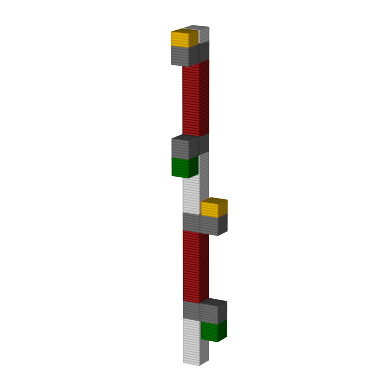

In [12]:
# have set rng
seed = 123456
rng = np.random.default_rng(seed)

simulator = DecodingSimulator()
# success, sim_params, device_data, window_data, decoding_data = simulator.run(
success_data, _, _ = simulator.run(
    schedule=t_schedule.schedule,
    distance=distance,
    scheduling_method=scheduling_method,
    decoding_latency_fn=lambda _: latency,
    speculation_mode=speculation_mode,
    speculation_latency=1,
    speculation_accuracy=speculation_accuracy,
    progress_bar=True,
    # rng=123456, # rng=rng
    need_full_window=False,
)
success, sim_params, device_data, window_data, decoding_data = success_data

ax = plotter.plot_device_schedule_trace(device_data, spacing=1)
ax.set_axis_off()

FULL WINDOW DAG STEP BEGIN---------------------------------
FULL WINDOW DAG STEP BEGIN---------------------------------
full window arr  []
full window dag  None
window params dict simulator None
discard 1  {(1, 0), (0, 0)} {(1, 0)}
discard 1  {(1, 0), (0, 0)} {(1, 0)}
discard 1  {(0, 1), (0, 0)} {(0, 1)}
discard 1  {(0, 1), (0, 0)} {(0, 1)}
discard 1  {(0, 0)} {(0, 0)}
schedule insts device manager after y_meas [InstructionTask(instruction_idx=0, instruction=Instruction(name='IDLE', idx=0, patches=frozenset({(0, 0)}), duration=3, conditioned_on_idx=frozenset(), conditional_dependencies=frozenset(), conditioned_on_completion_idx=frozenset(), conditional_completion_dependencies=frozenset(), merge_faces=frozenset(), group_instr_indices=frozenset(), group_name='', t_gate_bool=False, actual_duration_time=None), start_round=-1, end_round=-1), InstructionTask(instruction_idx=1, instruction=Instruction(name='IDLE', idx=1, patches=frozenset({(0, 0)}), duration=3, conditioned_on_idx=frozenset()

Surface code rounds: 155it [00:00, 2058.51it/s]


simulator device manager schedule insts run [InstructionTask(instruction_idx=0, instruction=Instruction(name='IDLE', idx=0, patches=frozenset({(0, 0)}), duration=3, conditioned_on_idx=frozenset(), conditional_dependencies=frozenset(), conditioned_on_completion_idx=frozenset(), conditional_completion_dependencies=frozenset(), merge_faces=frozenset(), group_instr_indices=frozenset(), group_name='', t_gate_bool=False, actual_duration_time=None), start_round=-1, end_round=-1), InstructionTask(instruction_idx=1, instruction=Instruction(name='IDLE', idx=1, patches=frozenset({(0, 0)}), duration=3, conditioned_on_idx=frozenset(), conditional_dependencies=frozenset(), conditioned_on_completion_idx=frozenset(), conditional_completion_dependencies=frozenset(), merge_faces=frozenset(), group_instr_indices=frozenset(), group_name='', t_gate_bool=False, actual_duration_time=None), start_round=-1, end_round=-1), InstructionTask(instruction_idx=2, instruction=Instruction(name='IDLE', idx=2, patches=fr

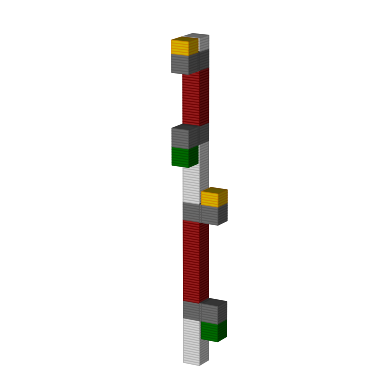

In [ ]:
# have set rng
seed = 123456
rng = np.random.default_rng(seed)

simulator = DecodingSimulator()
# success, sim_params, device_data, window_data, decoding_data = simulator.run(
success_data, full_window_arr, _ = simulator.run(
    schedule=t_schedule.schedule,
    distance=distance,
    scheduling_method=scheduling_method,
    decoding_latency_fn=lambda _: latency,
    speculation_mode=speculation_mode,
    speculation_latency=1,
    speculation_accuracy=speculation_accuracy,
    progress_bar=True,
    rng=123456, # rng=rng
    need_full_window=False,
    # window_parameters='window_parameters_file.json'
)
success, sim_params, device_data, window_data, decoding_data = success_data

ax = plotter.plot_device_schedule_trace(device_data, spacing=1)
ax.set_axis_off()

In [ ]:
# have set rng
seed = 123456
rng = np.random.default_rng(seed)

simulator = DecodingSimulator()
# success, sim_params, device_data, window_data, decoding_data = simulator.run(
success_data, _, _ = simulator.run(
    schedule=t_schedule.schedule,
    distance=distance,
    scheduling_method=scheduling_method,
    decoding_latency_fn=lambda _: latency,
    speculation_mode=speculation_mode,
    speculation_latency=1,
    speculation_accuracy=speculation_accuracy,
    progress_bar=True,
    # rng=123456, # rng=rng
    need_full_window=False,
    window_parameters='window_parameters_file.json'
)
success, sim_params, device_data, window_data, decoding_data = success_data

ax = plotter.plot_device_schedule_trace(device_data, spacing=1)
ax.set_axis_off()

### Variable Decoder Latency

Pre-generated PyMatching latencies are saved in `notebooks/data/decoder_dists.pkl` for distances 13 - 31

In [ ]:
decoder_dists = pkl.load(open('notebooks/data/decoder_dists.pkl', 'rb'))
distance = 13

# Inner decoder function takes as input the decoding volume in units of d^2
# Saved decoder dists are in units of d^3. Convert by dividing by distance and rounding up
sampled_latency = lambda vol: np.random.choice(decoder_dists[distance][max(2,int(np.ceil(vol / distance)))])

In [ ]:
success, sim_params, device_data, window_data, decoding_data = simulator.run(
    schedule=t_schedule.schedule,
    distance=distance,
    scheduling_method=scheduling_method,
    decoding_latency_fn=sampled_latency,
    speculation_mode=speculation_mode,
    speculation_latency=1,
    speculation_accuracy=speculation_accuracy,
    progress_bar=True,
)

ax = plotter.plot_device_schedule_trace(device_data, spacing=1)
ax.set_axis_off()

### Parallel with and without speculation

In [ ]:
speculation_method = 'parallel'

In [ ]:
success, sim_params, device_data, window_data, decoding_data = simulator.run(
    schedule=t_schedule.schedule,
    distance=distance,
    scheduling_method=speculation_method,
    decoding_latency_fn=lambda _: latency, # Fixed latency to reduce variance
    speculation_mode=speculation_mode,
    speculation_latency=1,
    speculation_accuracy=0, # 0% accuracy is equivalent to no speculation
    progress_bar=True,
)

ax = plotter.plot_device_schedule_trace(device_data, spacing=1)
ax.set_axis_off()

In [ ]:
success, sim_params, device_data, window_data, decoding_data = simulator.run(
    schedule=t_schedule.schedule,
    distance=distance,
    scheduling_method=scheduling_method,
    decoding_latency_fn=lambda _: latency, # Fixed latency to reduce variance
    speculation_mode=speculation_mode,
    speculation_latency=1,
    speculation_accuracy=speculation_accuracy,
    progress_bar=True,
)

ax = plotter.plot_device_schedule_trace(device_data, spacing=1)
ax.set_axis_off()

## Simulating Window Decoding for 15-to-1 Magic State Distillation

In [ ]:
from swiper.schedule_experiments import MSD15To1Schedule

In [ ]:
msd_schedule = MSD15To1Schedule()

latency = 14 # us
distance = 7 
scheduling_method = 'sliding' 
speculation_mode = 'separate' 
speculation_accuracy = 0.9


In [ ]:
success, sim_params, device_data, window_data, decoding_data = simulator.run(
    schedule=msd_schedule.schedule,
    distance=distance,
    scheduling_method=scheduling_method,
    decoding_latency_fn=lambda _: latency,
    speculation_mode=speculation_mode,
    speculation_latency=1,
    speculation_accuracy=speculation_accuracy,
    progress_bar=True,
)

ax = plotter.plot_device_schedule_trace(device_data, spacing=1)
ax.set_axis_off()

## Simulating Window Decoding for General Benchmarks

A set of pre-compiled schedules are included in `benchmarks/cached_schedules`.

Arbitrary cirq circuits can be compiled and simulated. See `benchmarks/benchmark_circuits.py` for examples of creating new benchmarks. However, if you would like to run your own benchmarks with SWIPER-SIM `gridsynth` and `lsqecc_slicer` executables are required to be in `benchmarks/` which are called by `cirq_to_ls.py`. See the following pages for installation: [gridsynth installation](https://www.mathstat.dal.ca/~selinger/newsynth/), [lsqecc_slicer installation](https://github.com/latticesurgery-com/liblsqecc)

In [ ]:
from swiper.lattice_surgery_schedule import LatticeSurgerySchedule

In [ ]:
adder = LatticeSurgerySchedule.from_str(open('benchmarks/cached_schedules/adder_n18.lss', 'r').read())

In [ ]:
latency = 14 # us
distance = 7 
scheduling_method = 'sliding' 
speculation_mode = 'separate' 
speculation_accuracy = 0.9

In [ ]:
success, sim_params, device_data, window_data, decoding_data = simulator.run(
    schedule=adder,
    distance=distance,
    scheduling_method=scheduling_method,
    decoding_latency_fn=lambda _: latency,
    speculation_mode=speculation_mode,
    speculation_latency=1,
    speculation_accuracy=speculation_accuracy,
    progress_bar=True,
)

ax = plotter.plot_device_schedule_trace(device_data, spacing=1, z_min=300, z_max=500)
ax.set_axis_off()